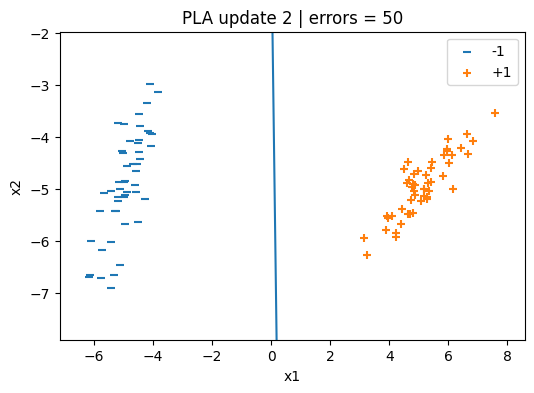

Converged!
Final w: [0.         8.34507387 0.19583971]
Iteration: 3


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from IPython.display import clear_output
import time

# --- data ---
X2, y01 = make_classification(
    n_samples=100, n_features=2, n_classes=2,
    n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=5,
    random_state=5
)
y = np.where(y01 == 0, -1, +1)

# bias trick
X = np.c_[np.ones(len(X2)), X2]

def predict_sign(X, w):
    return np.sign(X @ w)

def choose_miscl_point(w, X, y):
    idx = np.where(predict_sign(X, w) != y)[0]
    j = np.random.choice(idx)
    return X[j], y[j]

def plot_boundary(ax, w, xlim):
    xs = np.linspace(xlim[0], xlim[1], 200)
    # handle vertical / degenerate cases
    if abs(w[2]) < 1e-12:
        if abs(w[1]) < 1e-12:
            return
        ax.axvline(-w[0] / w[1])
    else:
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys)

# --- training + step-by-step display ---
w = np.zeros(X.shape[1])
max_updates = 200

xlim = (X2[:, 0].min() - 1, X2[:, 0].max() + 1)
ylim = (X2[:, 1].min() - 1, X2[:, 1].max() + 1)

for it in range(1, max_updates + 1):
    # compute errors BEFORE update (so title matches book style)
    errors = np.sum(predict_sign(X, w) != y)
    if errors == 0:
        # clear_output(wait=True)
        print("Converged!")
        break

    # update FIRST so we see a line immediately
    x_i, s = choose_miscl_point(w, X, y)
    w = w + s * x_i

    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(X2[y == -1, 0], X2[y == -1, 1], marker='_', label="-1")
    ax.scatter(X2[y == +1, 0], X2[y == +1, 1], marker='+', label="+1")
    plot_boundary(ax, w, xlim=xlim)

    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(f"PLA update {it} | errors = {errors}")
    ax.legend(loc="best")
    plt.show()

    time.sleep(0.6)

print("Final w:", w)
print("Iteration:", it)